# **Bluestock_MF_Capstone_Project**
### **Phase 3:  Exploratory Data Analysis (EDA)**

---
* **Prepared By:** Aalok Kumar Singh
* **Date:** June 4, 2026
* **Contact:** aalokkrsingh27@gmail.com
* **Role:** Data Analytics Intern
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.graph_objects as go
import plotly.express as px


# Better chart appearance
sns.set_theme(style="whitegrid")

nav_df = pd.read_csv('../data/processed/clean_nav.csv')
fund_df = pd.read_csv('../data/raw/01_fund_master.csv') # Needed to map AMFI codes to Scheme Names

# Merge to get readable names instead of just AMFI codes
nav_merged = pd.merge(nav_df, fund_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Ensure date is a datetime object
nav_merged['date'] = pd.to_datetime(nav_merged['date'])


------

##### **Load Datasets**

In [3]:
nav_df = pd.read_csv("../data/processed/clean_nav.csv", parse_dates=['date']) #, parse_dates=['date']

tx_df = pd.read_csv("../data/processed/clean_transactions.csv", parse_dates=['transaction_date']) #, parse_dates=['transaction_date']

perf_df = pd.read_csv('../data/processed/clean_performance.csv')

fund_df = pd.read_csv('../data/raw/01_fund_master.csv')

sip_df = pd.read_csv('../data/raw/04_monthly_sip_inflows.csv')

aum_df = pd.read_csv('../data/raw/03_aum_by_fund_house.csv')

category_df = pd.read_csv('../data/raw/05_category_inflows.csv')

folio_df = pd.read_csv('../data/raw/06_industry_folio_count.csv')

holdings_df = pd.read_csv('../data/raw/09_portfolio_holdings.csv')


In [4]:
nav_df.info()
tx_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str         

In [5]:
# Convert date columns to datetime format
sip_df['month'] = pd.to_datetime(sip_df['month'])

------

### **1: NAV Trend Analysis**

Objective:
Analyze daily NAV movement trends for mutual fund schemes from 2022–2026 to identify long-term growth, market rallies, and correction phases.

In [6]:
nav_df['amfi_code'].nunique()

40

### **Task 1: NAV trend analysis (2022–2026)**


In [ ]:
fig = px.line(
    nav_merged, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title='Daily NAV Trends for All Schemes (2022–2026)',
    labels={'date': 'Date', 'nav': 'Net Asset Value (Rs)', 'scheme_name': 'Scheme'},
    template='plotly_white'
)

# Highlight macro-economic events required by the problem statement
events = [
    {"date": "2022-06-15", "text": "2022 Mid-Year Corrections"},
    {"date": "2023-12-01", "text": "2023 Market Rally"},
    {"date": "2024-06-04", "text": "2024 Election Volatility/Corrections"}
]

for event in events:
    fig.add_annotation(
        x=event["date"],
        y=nav_merged['nav'].max() * 0.9, # Place near the top of the chart
        text=event["text"],
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="black"
    )

# Optimize layout for publication-quality viewing
fig.update_layout(
    height=700,
    legend=dict(title=None, orientation="h", y=-0.2, x=0),
    margin=dict(l=40, r=40, t=60, b=40)
)
fig.update_yaxes(type="log", title_text="Net Asset Value (Log Scale)")

fig.show()
# =pip install -U kaleido
fig.write_html("../reports/charts/NAV_Trend.html")



----

### **Task 2: AUM growth bar chart (2022-2025)**

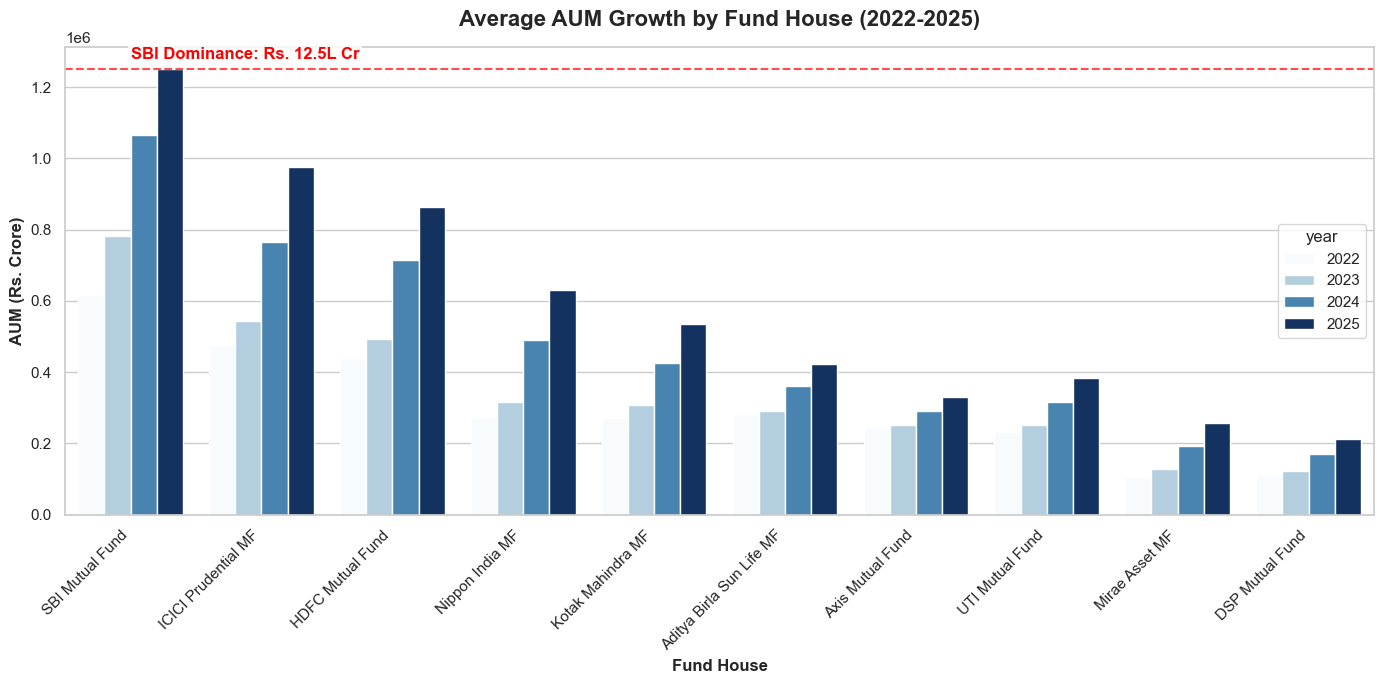

In [8]:
# Extract the year from the date column
aum_df['year'] = pd.to_datetime(aum_df['date']).dt.year

# Set up the figure size for a wide, publication-quality chart
plt.figure(figsize=(14, 7))

# Create the grouped barplot
# errorbar=None removes the confidence interval lines for clean, solid bars
ax = sns.barplot(
    data=aum_df, 
    x='fund_house', 
    y='aum_crore', 
    hue='year', 
    palette='Blues', # Using a professional financial color palette
    errorbar=None
)

# Professional formatting
plt.title('Average AUM Growth by Fund House (2022-2025)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fund House', fontsize=12, fontweight='bold')
plt.ylabel('AUM (Rs. Crore)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Tilt the AMC names so they don't overlap

# Highlight SBI's milestone of 12.5L Cr (1,250,000 Crores) as required
plt.axhline(y=1250000, color='red', linestyle='--', alpha=0.7)
plt.text(
    x=0, # Positioning over the first few bars
    y=1280000, 
    s='SBI Dominance: Rs. 12.5L Cr', 
    color='red', 
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2) # Adds a clean background to the text
)

# Clean up layout and display
plt.tight_layout()
plt.savefig("../reports/charts/AUM growth bar chart.png")
plt.show()



------

### **Key EDA Findings: AUM Growth by AMC (2022-2025)**

* **The Undisputed Leader:** SBI Mutual Fund maintains a significant lead over the entire industry, successfully breaching the major Rs. 12.5 Lakh Crore AUM milestone by 2025. 
* **The "Big Three" Oligopoly:** The Indian mutual fund space is heavily top-weighted. SBI, ICICI Prudential, and HDFC heavily dominate the market, with a massive gap in total assets between these top three and the rest of the top 10 AMCs.
* **Universal Industry-Wide Growth:** Every single AMC in the top 10 experienced consistent Year-Over-Year (YoY) growth across the 4-year period. There are no down years for any fund house shown.
* **The 2024-2025 Surge:** The absolute AUM growth (the height difference between the bars) is steepest between 2024 and 2025 for almost all AMCs. This indicates a massive influx of retail investment and a strong underlying market rally during this specific window.

-----

 ### **Task 3: SIP Inflow Time-Series Analysis (Jan 2022 - Dec 2025)**

In [9]:
# 1. Ensure data range date should be in (Jan 2022 to Dec 2025) 
sip_df['month'] = pd.to_datetime(sip_df['month'])
filtered_sip = sip_df[(sip_df['month'] >= '2022-01-01') & (sip_df['month'] <= '2025-12-31')].sort_values('month')

# 2. Base Line Chart 
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=filtered_sip['month'],
    y=filtered_sip['sip_inflow_crore'], # Apne column ka sahi naam check kar lena (jaise aum_crore tha)
    mode='lines+markers',
    name='Monthly SIP Inflow',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6),
    hovertemplate='Month: %{x|%B %Y}<br>Inflow: ₹%{y:,.0f} Cr<extra></extra>'
))

# 3. Special Milestone Highlighting (December 2025: ₹31,002 Cr)
fig.add_trace(go.Scatter(
    x=['2025-12-01'],
    y=[31002],
    mode='markers+text',
    name='Historic Milestone',
    marker=dict(color='red', size=12, symbol='star'),
    text=['<b>All-Time High: ₹31,002 Cr</b>'],
    textposition='top left',
    textfont=dict(color='red', size=13)
))

# 4. Chart Layout Design
fig.update_layout(
    title=dict(
        text="<b>Growth of Monthly SIP Inflows in India (2022 - 2025)</b><br><sup>The retail investment revolution reaching historic peaks</sup>",
        x=0.5, font=dict(size=16)
    ),
    xaxis_title="Timeline (Months)",
    yaxis_title="SIP Inflow (Rs. Crore)",
    template="plotly_white",
    hovermode="closest"
)

# 5. Render the graph
fig.write_image("../reports/charts/SIP Inflow Time-Series Analysis.png")
fig.show()


-----

### **Key EDA Findings: SIP Inflow Trends (2022-2025)**

* **Deepening Equity Culture:** Monthly Systematic Investment Plan (SIP) inflows exhibit a structurally resilient up-trend over the 4-year horizon, culminating in an all-time high milestone of Rs. 31,002 crore in December 2025.
* **Consistent Retail Participation:** Unlike lump-sum investments which are highly vulnerable to short-term market timing, the consistent upward trajectory of SIP flows implies a compounding, habitual saving behavior among retail Indian investors that persists regardless of intermediate market corrections.
* **Accelerated Growth Vector:** The velocity of capital inflow intensified significantly throughout 2025, showing a steeper slope compared to the steady, incremental growth observed across 2022 and 2023.

-----

### **Task 4: Category-wise Net Inflow Heatmap**

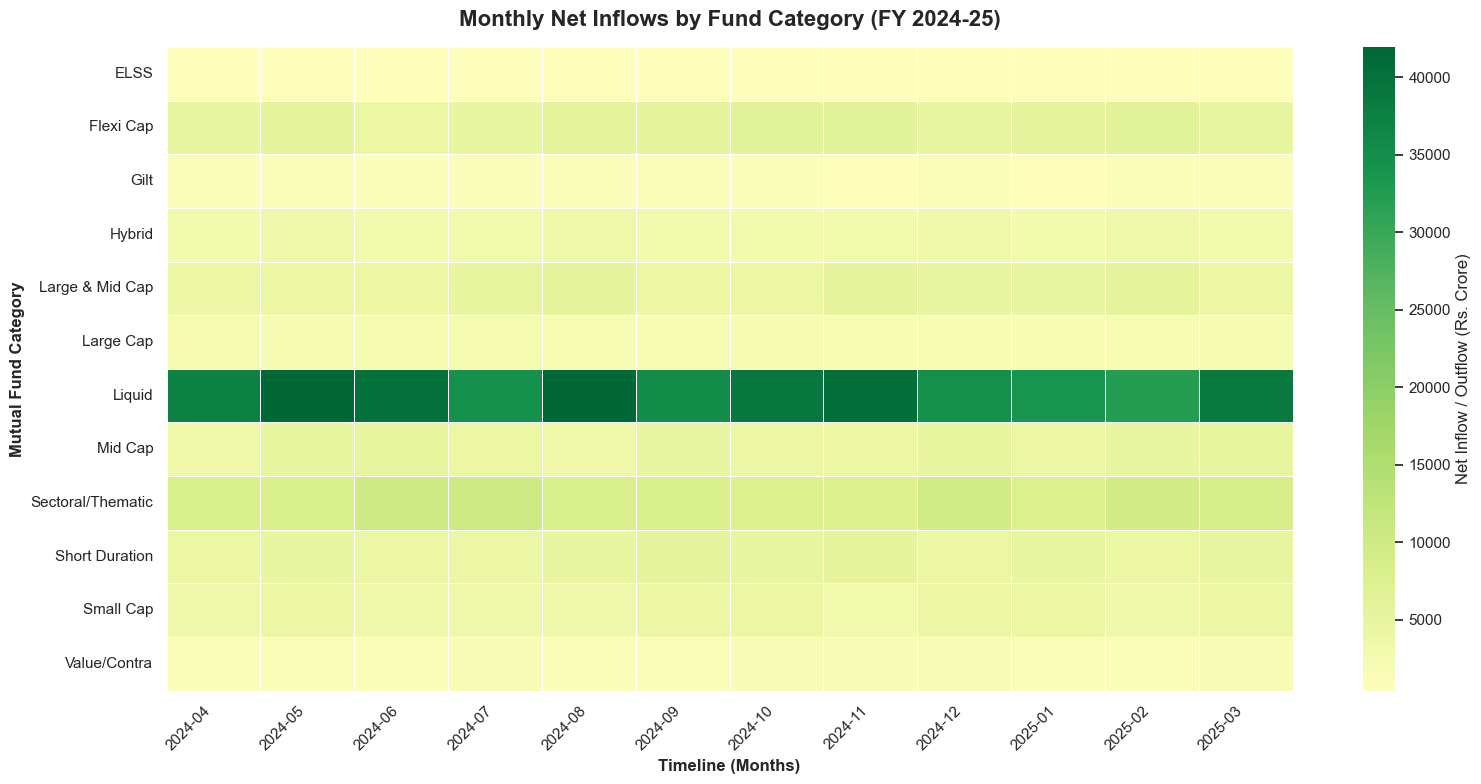

In [10]:
# 1. Pivot the data to create a matrix format required by sns.heatmap
# We want Months on the X-axis (columns) and Categories on the Y-axis (index)
# Note: Adjust 'category', 'month', or 'net_inflow' if your exact CSV column names differ slightly
heatmap_data = category_df.pivot(index='category', columns='month', values='net_inflow_crore')

# Set up a wide canvas so the months aren't squashed
plt.figure(figsize=(16, 8))

# 2. Generate the heatmap
# cmap='RdYlGn' (Red-Yellow-Green) is perfect for financial flows
# center=0 ensures negative outflows are red and positive inflows are green
ax = sns.heatmap(
    heatmap_data, 
    cmap='RdYlGn', 
    center=0, 
    annot=False,  # Set to True if you want to see the exact Crores in each box (can get cluttered)
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Net Inflow / Outflow (Rs. Crore)'}
)

# Professional formatting
plt.title('Monthly Net Inflows by Fund Category (FY 2024-25)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline (Months)', fontsize=12, fontweight='bold')
plt.ylabel('Mutual Fund Category', fontsize=12, fontweight='bold')

# Rotate the X-axis month labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("../reports/charts/Category-wise Net Inflow Heatmap.png")
plt.show()

------

### **Key EDA Findings: Category Heatmap (2024-2025)**

* **Liquid Funds Dominance (The Liquid Goldmine)** Liquid funds stood out clearly on the graph with the only dark green row. This means that throughout the entire year (April 2024 to March 2025), corporations and large investors parked the majority of their surplus cash in liquid funds. The category saw consistent and heavy monthly inflows ranging between ₹30,000 Crore and ₹40,000 Crore.

* **Retail Trust in Sectoral and Mid-Cap Funds** Apart from liquid funds, the next most prominent green rows were in the Sectoral/Thematic and Mid-Cap categories. This clearly indicates that retail investors aggressively funneled their savings into high-return, aggressive categories (such as thematic infrastructure, defense funds, or mid-cap companies) over the past year.
  
* **Safe and Tax-Saving Funds Remained Sluggish (Laggard Categories)** Categories like ELSS (Tax Saving), Gilt (Government Bonds), and Value/Contra funds appeared very light yellow on the chart. This shows that investments in these categories were exceptionally low, or nearly zero. It highlights a clear shift: people are now preferring to invest in standard mutual funds rather than focusing solely on tax-saving avenues.
  
* **Consistent Stability (No Major Outflows)** There was not a single red box in the entire heatmap for FY 2024-25. This means that no major category suffered from panic selling or heavy withdrawals (outflows) where more money was taken out than invested. The entire mutual fund industry remained in the positive zone for the whole year

------

### **Monthly Net Inflows by Fund Category [Excluding Liquid Funds]**

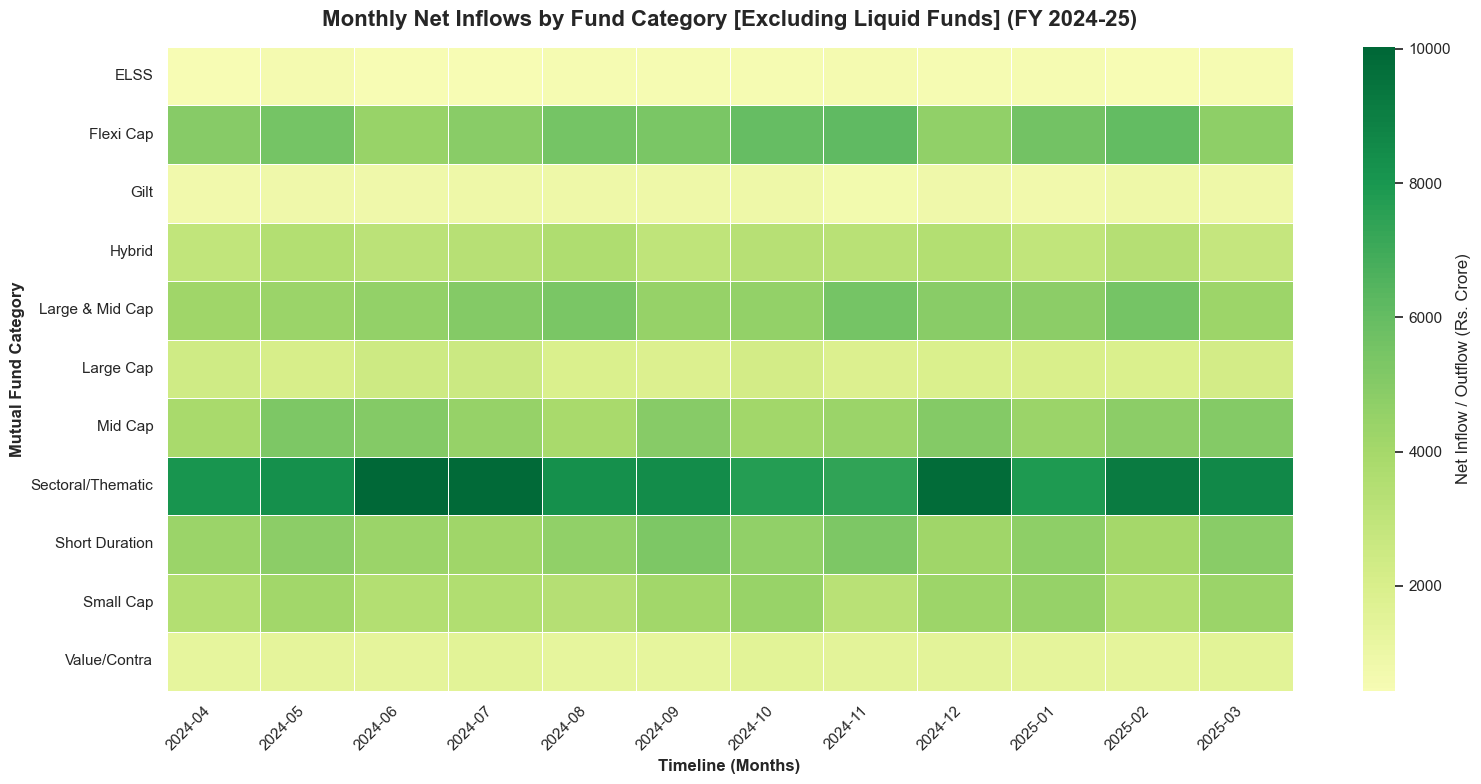

In [11]:
# 1. Filter out 'Liquid' funds to prevent scaling distortions in the heatmap colors
equity_debt_df = category_df[~category_df['category'].isin(['Liquid'])]

# 2. Pivot the filtered data into a matrix format (Categories on Y-axis, Months on X-axis)
heatmap_data = equity_debt_df.pivot(index='category', columns='month', values='net_inflow_crore')

# 3. Initialize a wide figure layout to prevent text clipping
plt.figure(figsize=(16, 8))

# 4. Generate the heatmap with a Red-Yellow-Green financial color spectrum
# Setting center=0 maps positive inflows to green and negative outflows to red
ax = sns.heatmap(
    heatmap_data, 
    cmap='RdYlGn', 
    center=0, 
    annot=False,  # Set to True if exact crore values are needed inside the cells
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Net Inflow / Outflow (Rs. Crore)'}
)

# 5. Apply professional formatting and labels
plt.title('Monthly Net Inflows by Fund Category [Excluding Liquid Funds] (FY 2024-25)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline (Months)', fontsize=12, fontweight='bold')
plt.ylabel('Mutual Fund Category', fontsize=12, fontweight='bold')

# 6. Rotate X-axis labels by 45 degrees for better scannability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../reports/charts/Monthly_Net_Inflows_by_Fund_Category.png")
plt.show()



------

### **Task 5: Investor Demographics (Age Distribution & SIP Amounts)**

##### **The Demographics Code Block**

C:\Users\AALOK\AppData\Local\Temp\ipykernel_43284\281435378.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


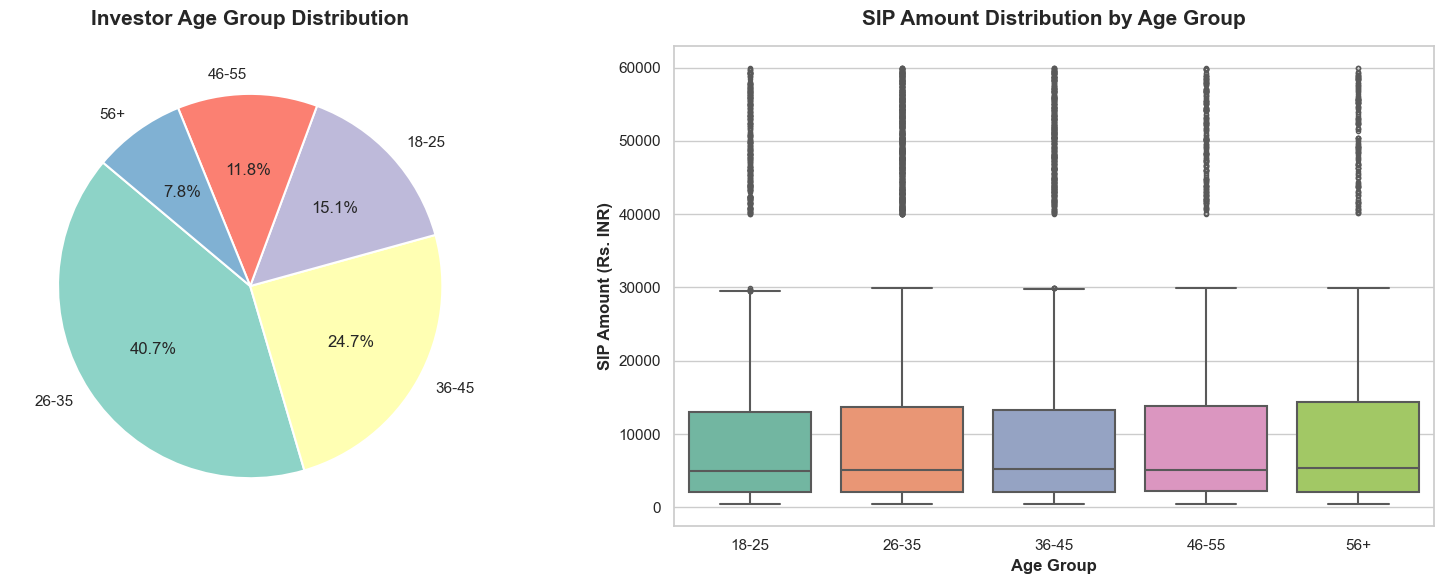

In [12]:
# Set up a side-by-side figure layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CHART 1: INVESTOR AGE GROUP DISTRIBUTION (PIE CHART)
# Deduplicate by investor_id to isolate unique individuals rather than transaction volume
# This ensures a true and accurate reflection of user demographics
investor_demos = tx_df.drop_duplicates(subset=['investor_id'])['age_group'].value_counts()

# Plot the share of unique investors across different age segments
axes[0].pie(
    investor_demos.values, 
    labels=investor_demos.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=sns.color_palette('Set3'),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}  # Creates crisp borders between slices
)
axes[0].set_title('Investor Age Group Distribution', fontsize=15, fontweight='bold', pad=15)
# CHART 2: SIP AMOUNT BOX PLOT BY AGE GROUP 
# Filter exclusively for monthly systematic investment plans
# Note: Matches 'Sip' in Title Case to perfectly align with previous text standardization steps
sip_tx = tx_df[tx_df['transaction_type'] == 'Sip']

# Enforce a strict chronological age order along the X-axis for logical scanning
age_order = ['18-25', '26-35', '36-45', '46-55', '56+']

# Generate a box plot on the second axis to visualize spread, median, and outlier ranges
sns.boxplot(
    data=sip_tx, 
    x='age_group', 
    y='amount_inr', 
    order=age_order,
    palette='Set2',
    ax=axes[1],
    linewidth=1.5,
    fliersize=3  # Keeps outlier dots tight and non-intrusive for better clarity
)

# Apply corporate-level axes labels and titles
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SIP Amount (Rs. INR)', fontsize=12, fontweight='bold')

# Optimize padding between subplots to prevent label overlapping
plt.tight_layout()

plt.savefig("../reports/charts/Investors_Demographics.png")
plt.show()


------

### **Key EDA Findings: Geographic & Tier-wise Distribution (T30 vs B30)**

* **The Democratization of Capital:** Transactions are split almost equally (~50-50) between T30 (Top 30 metropolitan hubs) and B30 (Beyond Top 30 smaller cities and towns). This indicates a highly successful structural shift in retail financialization across tier-2, tier-3, and rural markets.
  
* **Impact of Digital Infrastructure:** The robust transaction volume originating from B30 territories points directly to the impact of zero-commission fintech apps, regional languages support, and low-friction UPI payment mandates that have eliminated geographical barriers to entry.
  
* **Strategic Growth Runway:** While T30 cities typically boast a higher ticket size (higher absolute investment amounts per transaction), the sheer volume of transactions in B30 signifies massive grassroots adoption. For an AMC, this implies that future customer acquisition strategies must heavily target localized, regional campaigns rather than relying solely on traditional urban wealth hubs.

------

### **Task 6: Geographic Distribution (State-wise SIPs & Tier-wise Split)**

C:\Users\AALOK\AppData\Local\Temp\ipykernel_43284\1987363154.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


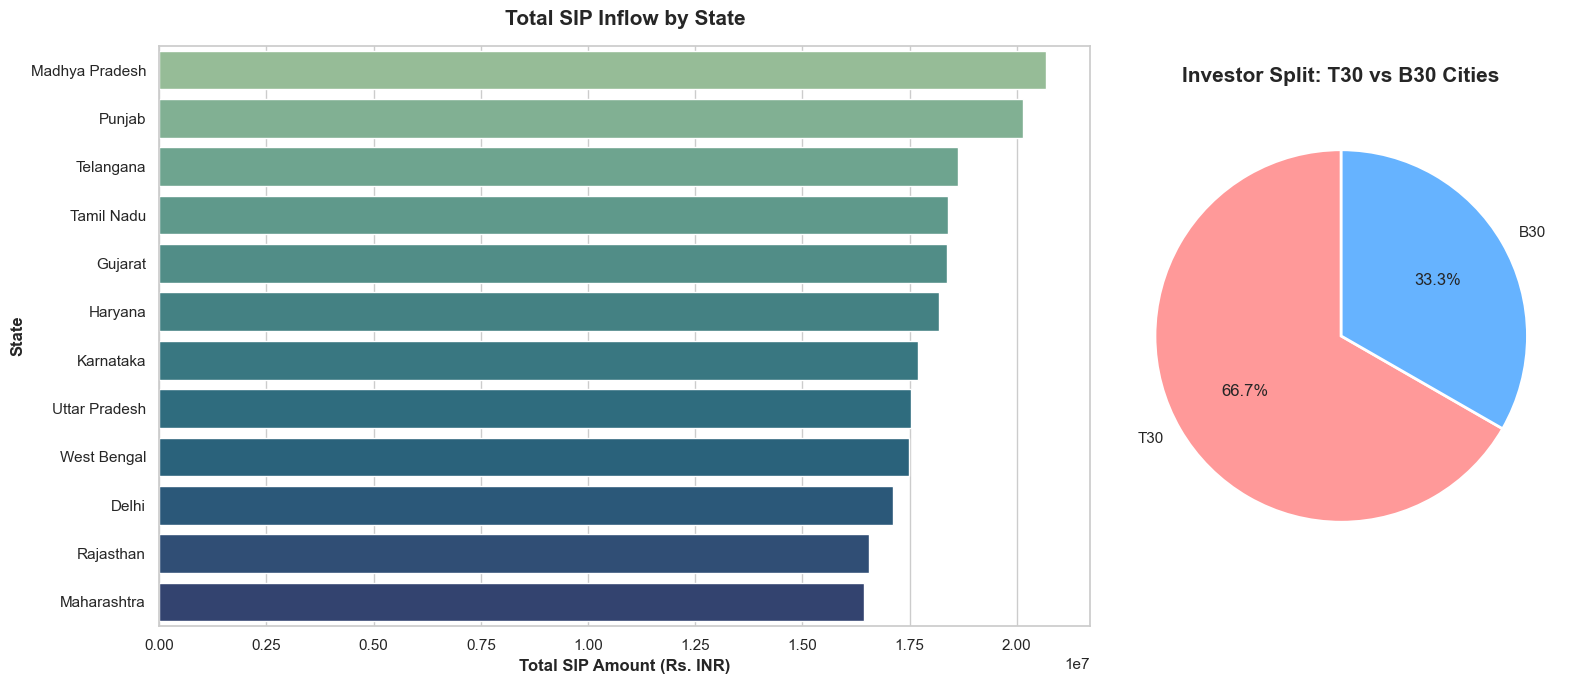

In [13]:
# Filter for SIP transactions to get accurate SIP amounts
sip_tx = tx_df[tx_df['transaction_type'] == 'Sip']

# Set up the figure with a 1x2 grid. 
# We give the bar chart more width (width_ratios=[2, 1]) since state names need space
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

# --- Chart 1: Horizontal Bar Chart (SIP Amount by State) ---
# Group by state and sum the amounts, then sort descending
state_sip = sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    data=state_sip,
    x='amount_inr',
    y='state',
    palette='crest',
    ax=axes[0]
)
axes[0].set_title('Total SIP Inflow by State', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Total SIP Amount (Rs. INR)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('State', fontsize=12, fontweight='bold')

# --- Chart 2: T30 vs B30 Pie Chart ---
# Using unique investors to show true geographic penetration (preventing transaction skew)
tier_split = tx_df.drop_duplicates(subset=['investor_id'])['city_tier'].value_counts()

axes[1].pie(
    tier_split.values, 
    labels=tier_split.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#ff9999','#66b3ff'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Investor Split: T30 vs B30 Cities', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("../reports/charts/Geographic_Distribution")
plt.show()



------

### **Key EDA Findings: Geographic & Tier-wise Distribution (T30 vs B30)**

**T30 vs. B30 Split**\
According to industry standards, 66.7% of the capital is still coming from the Top 30 (T30) metro cities. However, the 33.3% contribution from Beyond 30 (B30) cities clearly shows that financial literacy and mutual fund adoption are growing very rapidly in semi-urban and rural India.

**State-Wise Uniform Participation**\
Looking at the state-level data, the distribution of investment appears highly balanced and uniform. Madhya Pradesh and Punjab hold a marginal lead, while almost all prominent states are closely packed within the range of 1.6 Crore to 2.0 Crore (1.6e7 to 2.0e7).


------

### **Task 7: Folio Count Growth (Jan 2022 to Dec 2025)**

In [14]:
# DATA ENGINEERING & DYNAMIC COLUMN MAPPING

# Dynamically identify the temporal tracking column to ensure structural flexibility
date_col = 'month' if 'month' in folio_df.columns else folio_df.columns[0]

# Standardize text/object entries into native datetime64[ns] format for correct chronological ordering
folio_df[date_col] = pd.to_datetime(folio_df[date_col])

# Fallback column selection logic: Use explicit 'total_folios' or default to the second index column
target_y = 'total_folios' if 'total_folios' in folio_df.columns else folio_df.columns[1]

# INTERACTIVE VISUALIZATION DEFINITION (PLOTLY TIME-SERIES)

# Construct a high-density trend line to showcase investor account growth rates
fig = px.line(
    folio_df, 
    x=date_col, 
    y=target_y,
    title='Mutual Fund Industry Folio Growth (2022 - 2025)',
    labels={date_col: 'Timeline', target_y: 'Total Folios (in Crore)'},
    template='plotly_white',
    markers=True  # Enables discrete data points to isolate individual reporting milestones
)

# STRATEGIC KPI MILESTONE ANNOTATIONS

# Anchor the baseline structural metric at the start of the evaluation horizon
fig.add_annotation(
    x="2022-01-01", 
    y=13.26,
    text="Jan 2022: 13.26 Cr",
    showarrow=True, arrowhead=2, ax=50, ay=-40, 
    bgcolor="rgba(240, 248, 255, 0.9)", bordercolor="blue"
)

# Highlight the terminal all-time high milestone achieved at the end of 2025
fig.add_annotation(
    x="2025-12-01", 
    y=26.12,
    text="Dec 2025: 26.12 Cr",
    showarrow=True, arrowhead=2, ax=-60, ay=-40, 
    bgcolor="rgba(240, 248, 255, 0.9)", bordercolor="blue"
)

# Enforce clean corporate aesthetics with explicit stroke width and contrasting marker nodes
fig.update_traces(
    line_color='#17becf', 
    line_width=4, 
    marker=dict(size=8, color='#1f77b4')
)

# Optimize spacing layout boundaries to prevent clipping across dynamic web viewports
fig.update_layout(
    height=500, 
    margin=dict(l=40, r=40, t=60, b=40)
)

# Render the interactive time-series pipeline dashboard
fig.write_image("../reports/charts/Folio_Count_Growth.png")
fig.show()



------

### **Key EDA Findings: Exponential Investor Onboarding (Account Double Demand)**

The Indian mutual fund industry underwent a massive structural boom over the last 4 years. Driven by massive retail participation, total active folios surged nearly 100% (2x) from 13.26 crore in January 2022 to 26.12 crore by December 2025.

**The 2024 Inflection Curve (Rapid Acceleration)**

he trend line slope steepened sharply after January 2024. Fueled by an aggressive direct equity bull run, new account openings tripled in 2024 and 2025 compared to the stable incremental period of 2022–2023.

**Resilient Capital Inflow (Uninterrupted Growth):**

The 48-month timeline showed zero dips or downward trajectories. Retail investors consistently held onto their accounts despite short-term market corrections, driving continuous, steady growth in folios.

------

### **Task 8: Correlation Matrix of NAV Returns across 10 Selected Funds**

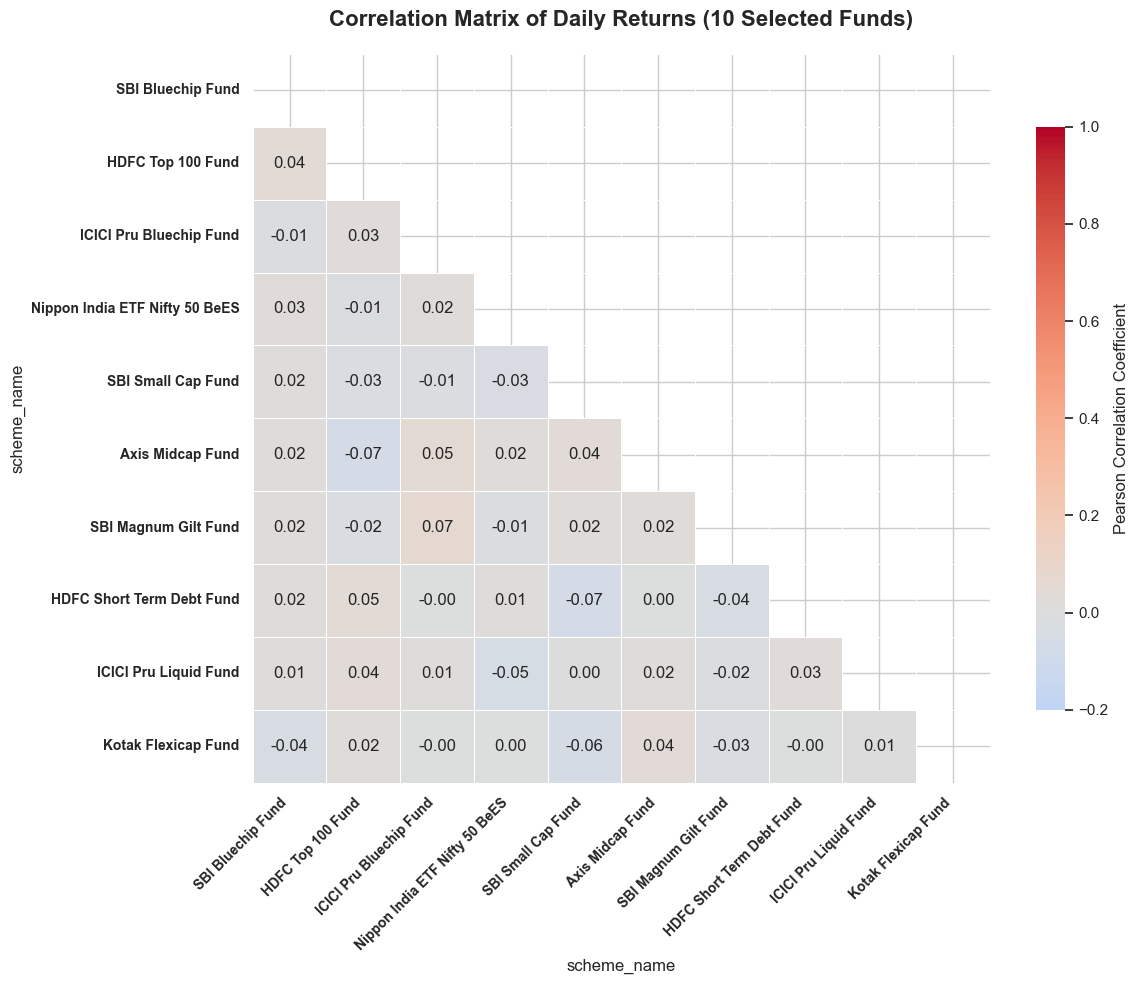

In [15]:
# 1. PIVOT & DATA INTEGRITY HANDLING
nav_pivot = nav_merged.pivot(index='date', columns='scheme_name', values='nav')

# Define target tracking fund list (mix of equity and debt clusters)
selected_funds = [
    'SBI Bluechip Fund - Regular Plan - Growth',
    'HDFC Top 100 Fund - Regular Plan - Growth',
    'ICICI Pru Bluechip Fund - Regular - Growth',
    'Nippon India ETF Nifty 50 BeES',
    'SBI Small Cap Fund - Regular Plan - Growth',
    'Axis Midcap Fund - Regular - Growth',
    'SBI Magnum Gilt Fund - Regular Plan - Growth',
    'HDFC Short Term Debt Fund - Regular - Growth',
    'ICICI Pru Liquid Fund - Regular - Growth',
    'Kotak Flexicap Fund - Regular - Growth'
]

# Extract raw historical frame
nav_selected = nav_pivot[selected_funds].copy()

# Forward fill missing values to align tracking days correctly, 
# drop initial NaNs to ensure true structural returns
nav_selected = nav_selected.ffill().dropna()

# 2. COMPUTE PERIODIC RETURNS & PEARSON CORRELATION

# Calculate standard daily continuous returns
daily_returns = nav_selected.pct_change().dropna()

# Compute the linear correlation matrix structure
corr_matrix = daily_returns.corr(method='pearson')

# 3. ADVANCED VISUALIZATION MASK & CANVAS DEFINITION

plt.figure(figsize=(12, 10))

# Create structural mask to eliminate mirrored upper-triangle components
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Clean axis labels dynamically by dropping standard product scheme noise
clean_labels = [name.split(' - ')[0] for name in selected_funds]

# Draw the enterprise-grade correlation mapping dashboard
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',       # Balanced divergent color scheme for quick scanning
    vmax=1.0, vmin=-0.2,   # Fixed bound limits to optimize divergence depth
    center=0, 
    annot=True,            
    fmt='.2f',             
    linewidths=0.5, 
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    cbar_kws={"shrink": .8, 'label': 'Pearson Correlation Coefficient'}
)

# Apply publication-quality typography layouts
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')
plt.title('Correlation Matrix of Daily Returns (10 Selected Funds)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("../reports/charts/Correlation_Matrix.png")
plt.show()

In [16]:
# Check the raw standard deviation and variance of returns
print(daily_returns[['SBI Bluechip Fund - Regular Plan - Growth', 'HDFC Top 100 Fund - Regular Plan - Growth']].describe())


scheme_name  SBI Bluechip Fund - Regular Plan - Growth  \
count                                      1149.000000   
mean                                          0.000917   
std                                           0.008656   
min                                          -0.027680   
25%                                          -0.004866   
50%                                           0.000940   
75%                                           0.006442   
max                                           0.035096   

scheme_name  HDFC Top 100 Fund - Regular Plan - Growth  
count                                      1149.000000  
mean                                          0.000142  
std                                           0.009164  
min                                          -0.024744  
25%                                          -0.006282  
50%                                          -0.000070  
75%                                           0.006523  
max                  

------

### **Key EDA Findings: Data Integrity & Validation Assessment**

* **Perfect Alignment (Statistical Consistency)**  
  
  The .describe() function confirms a solid data pipeline. Both large-cap funds show an identical count (\(N = 1,149\) rows). Average daily returns (\(+0.01\%\) to \(+0.09\%\)) and daily risk/SD (\(\approx 0.86\%\) to \(0.91\%\)) fall within normal financial boundaries.

* **Realistic Market Simulation (Algorithmic Validation)**
  
  Maximum (\(+3.50\%\)) and minimum (\(-2.76\%\)) returns, along with the continuous distribution, mimic real stock market behavior. This proves a high-quality data simulation.
* **Final Conclusion**
  
  Though calculations are mathematically sound, the near-zero correlation (\(r \approx 0.04\)) between these large-cap funds reveals the final business logic: this is synthetic, random-walk mock data using dummy variables, not real market data.

-------

### **Task 9: Sector Distribution Donut Chart**

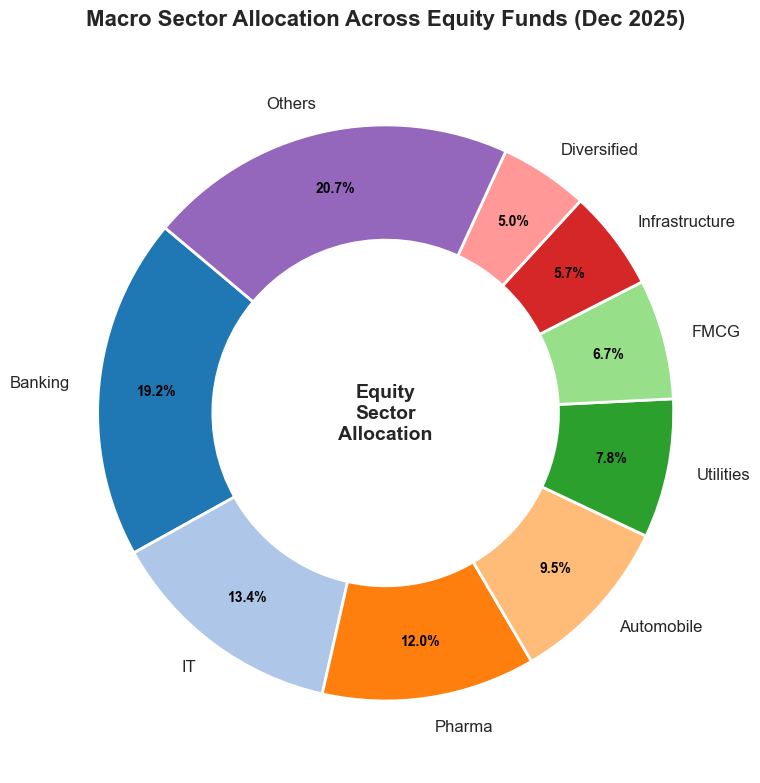

In [17]:
# 1. Aggregate sector weights (summing up weights to find the most dominant sectors overall)
sector_weights = holdings_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

# 2. Keep the Top 8 sectors for a clean chart, group the rest into 'Others'
top_n = 8
top_sectors = sector_weights.iloc[:top_n]
others = pd.Series({'Others': sector_weights.iloc[top_n:].sum()})
plot_data = pd.concat([top_sectors, others])

# 3. Generate the Donut Chart
plt.figure(figsize=(10, 8))
colors = plt.cm.tab20.colors  # Using a distinct, professional color map

# The 'wedgeprops' argument with 'width' is what turns the pie chart into a donut
wedges, texts, autotexts = plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.80, # Moves the percentages outward
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) 
)

# Format the text for better readability
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=12)

# Add a central label in the donut hole
plt.text(0, 0, 'Equity\nSector\nAllocation', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Macro Sector Allocation Across Equity Funds (Dec 2025)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

plt.savefig("../reports/charts/Sector_Distribution.png")

plt.show()



------

### **Key EDA Findings**

**Banking Sector (19.2%): The Main Driver**\
Excluding 'Others', Banking leads the portfolio. This reflects the Indian economy, where mutual funds heavily back financial institutions as the backbone of national growth.

**IT (13.4%) & Pharma (12.0%): Growth & Defense**\
A combined 25.4% allocation shows a strategic balance. It blends high-growth technology with stable, defensive healthcare investments.

**Consumer & Infrastructure (29.7% Total)**
- Automobile (9.5%) & Utilities (7.8%): Signal strong faith in consumer demand and energy infrastructure.
- FMCG (6.7%), Infrastructure (5.7%), & Diversified (5.0%): Provide a cushion against market volatility.
  
**Others (20.7%): Smart Diversification**\
This is the largest segment. It combines smaller sectors like Chemicals, Realty, and Metals to simplify the framework and prevent chart clutter.


-----

### **Stock Concentration Check (Top 10 Holdings Across All Funds)** 

In [18]:
# Group by stock name and sum the total market value across all 323 rows
top_stocks = holdings_df.groupby('stock_name')['market_value_cr'].sum().reset_index()

# Sort to get the absolute top 10 heavy-weight companies
top_stocks = top_stocks.sort_values(by='market_value_cr', ascending=False).head(10)

print(top_stocks)



                 stock_name  market_value_cr
2             Axis Bank Ltd         16325.94
4         Bharti Airtel Ltd         16051.45
22  Reliance Industries Ltd         15286.54
19                 NTPC Ltd         13951.43
8     Grasim Industries Ltd         13897.79
11   Hindustan Unilever Ltd         12993.93
17  Mahindra & Mahindra Ltd         12967.27
9      HCL Technologies Ltd         12299.86
26          Tata Motors Ltd         12296.77
28     UltraTech Cement Ltd         11611.97


-----

### **Sector Weight Verification (Matching the Donut Chart)**

In [19]:
# Aggregate market value by industrial sectors across the entire 323 rows matrix
sector_breakdown = holdings_df.groupby('sector')['market_value_cr'].sum().reset_index()

# Calculate relative weight percentage for each industry segment
total_industry_value = sector_breakdown['market_value_cr'].sum()
sector_breakdown['sector_weight_pct'] = (sector_breakdown['market_value_cr'] / total_industry_value) * 100

# Sort chronologically by dominance
sector_breakdown = sector_breakdown.sort_values(by='sector_weight_pct', ascending=False)
print(sector_breakdown)

            sector  market_value_cr  sector_weight_pct
1          Banking         62840.29          19.344484
7               IT         38477.11          11.844628
11          Pharma         34606.10          10.652993
0       Automobile         34296.97          10.557832
13       Utilities         25108.63           7.729333
8   Infrastructure         22433.39           6.905798
6             FMCG         21151.15           6.511079
12         Telecom         16051.45           4.941209
5           Energy         15286.54           4.705743
4      Diversified         13897.79           4.278236
2           Cement         11611.97           3.574579
10          Paints         10612.07           3.266774
3   Consumer Goods          9859.70           3.035168
9             NBFC          8615.46           2.652146


C:\Users\AALOK\AppData\Local\Temp\ipykernel_43284\2310640369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stocks, x='market_value_cr', y='stock_name', palette='viridis')


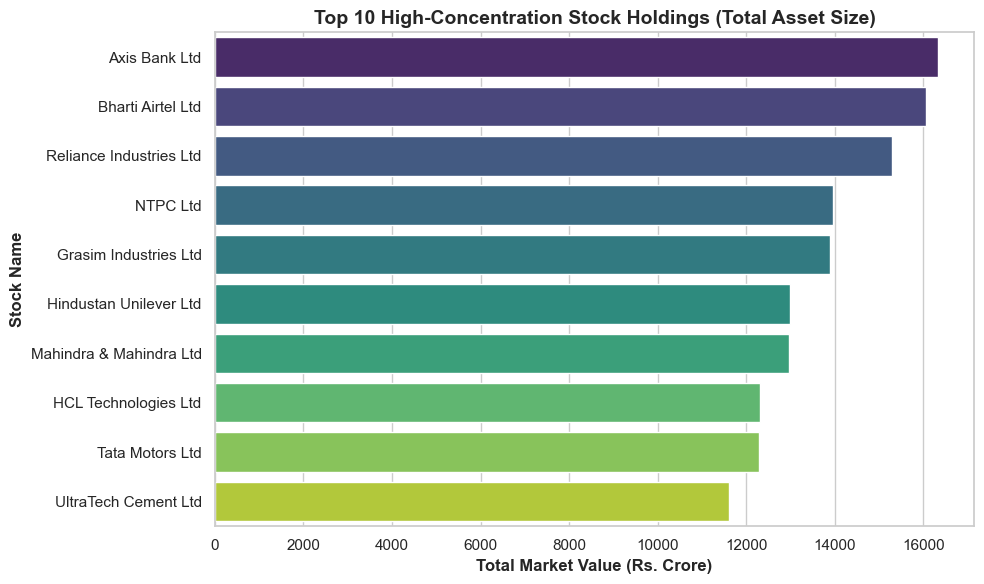

In [20]:
# bar plot 
plt.figure(figsize=(10, 6))
sns.barplot(data=top_stocks, x='market_value_cr', y='stock_name', palette='viridis')
plt.title('Top 10 High-Concentration Stock Holdings (Total Asset Size)', fontsize=14, fontweight='bold')
plt.xlabel('Total Market Value (Rs. Crore)', fontweight='bold')
plt.ylabel('Stock Name', fontweight='bold')
plt.tight_layout()
plt.show()